# Tutorial 12: Pictures Worth Numbers

**Programming Design Principles / Maths for IT**

In the last tutorial we built statistical tools and made our first histogram. Today we go deeper into data visualisation: how to choose the right type of chart, how to make charts that communicate clearly, and how to use visualisation as a tool for understanding rather than just decoration.

This is also an opportunity to practise writing clean, modular code -- wrapping common plotting tasks into reusable functions.

## Why Visualise?

Consider Anscombe's Quartet: four datasets that have nearly identical statistical properties (same mean, same standard deviation, same correlation) but look completely different when plotted. The statistics alone cannot distinguish them. The plots make the differences obvious.

Let's see this in action:

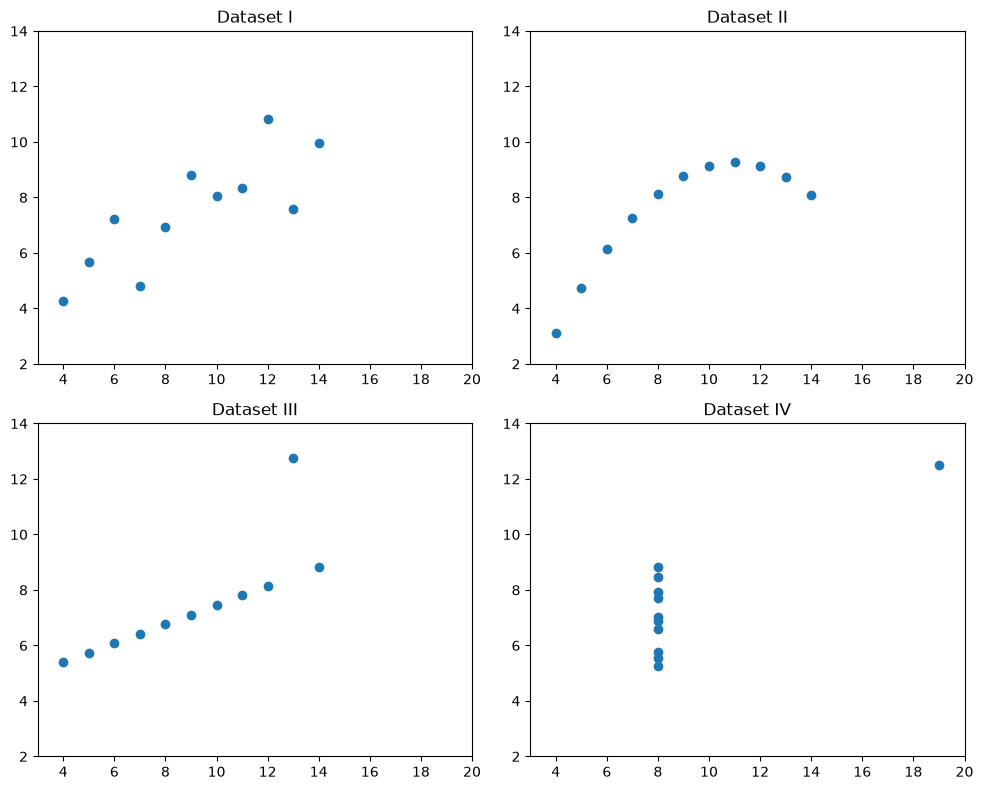

In [1]:
import matplotlib.pyplot as plt

# Anscombe's Quartet
datasets = {
    "I":   {"x": [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
             "y": [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]},
    "II":  {"x": [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
             "y": [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]},
    "III": {"x": [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
             "y": [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]},
    "IV":  {"x": [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8],
             "y": [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89]},
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (name, data) in zip(axes.flat, datasets.items()):
    ax.scatter(data["x"], data["y"])
    ax.set_title("Dataset " + name)
    ax.set_xlim(3, 20)
    ax.set_ylim(2, 14)
plt.tight_layout()
plt.show()

Same statistics, wildly different stories. This is why visualisation matters: it shows you what numbers cannot.

## Choosing the Right Chart

Different types of data call for different types of charts:

**Histogram**: shows the distribution of a single numerical variable. How often does each range of values occur?

**Bar chart**: compares quantities across categories. How many students prefer each programming language?

**Line chart**: shows trends over time or across an ordered sequence. How did temperature change throughout the day?

**Scatter plot**: shows the relationship between two numerical variables. Is there a connection between hours studied and test scores?

**Pie chart**: shows proportions of a whole. What fraction of students passed, got merit, or got distinction? (Use sparingly -- bar charts are usually clearer.)

### Making a bar chart

Let's say we surveyed students about their favourite programming language:

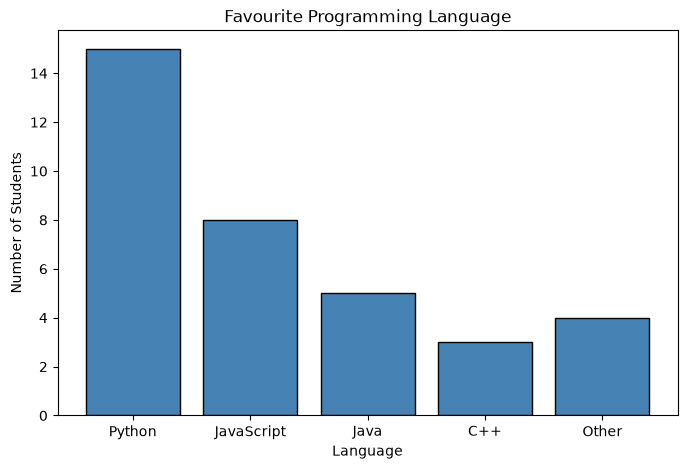

In [2]:
languages = ["Python", "JavaScript", "Java", "C++", "Other"]
counts = [15, 8, 5, 3, 4]

plt.figure(figsize=(8, 5))
plt.bar(languages, counts, color='steelblue', edgecolor='black')
plt.xlabel('Language')
plt.ylabel('Number of Students')
plt.title('Favourite Programming Language')
plt.show()

### Making a line chart

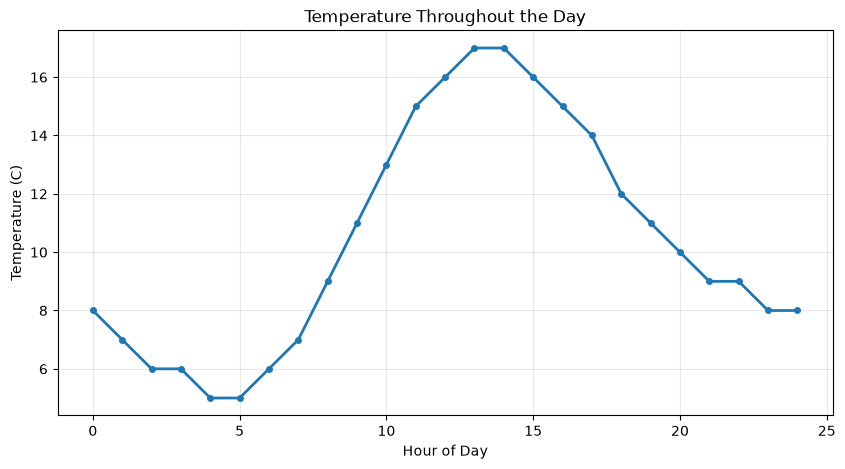

In [3]:
hours = list(range(0, 25))
temperatures = [8, 7, 6, 6, 5, 5, 6, 7, 9, 11, 13, 15, 
                16, 17, 17, 16, 15, 14, 12, 11, 10, 9, 9, 8, 8]

plt.figure(figsize=(10, 5))
plt.plot(hours, temperatures, marker='o', linewidth=2, markersize=4)
plt.xlabel('Hour of Day')
plt.ylabel('Temperature (C)')
plt.title('Temperature Throughout the Day')
plt.grid(True, alpha=0.3)
plt.show()

### Making a scatter plot

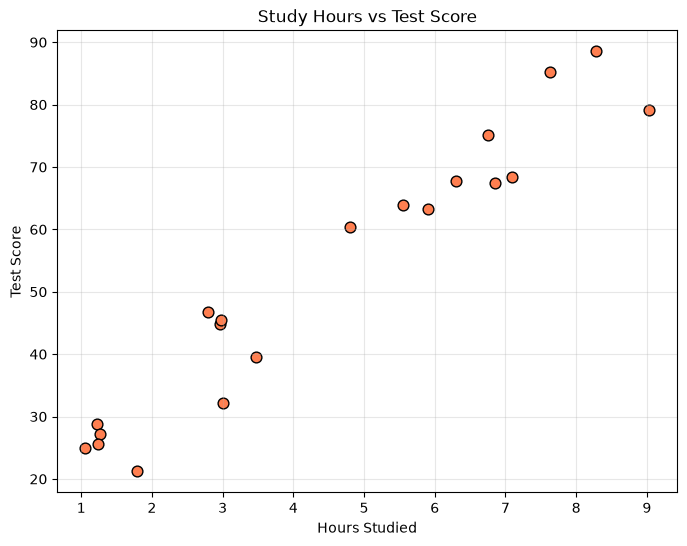

In [4]:
# Study hours vs test scores for 20 students
import random
random.seed(42)

study_hours = [random.uniform(1, 10) for _ in range(20)]
test_scores = [min(100, max(20, hours * 8 + random.uniform(-10, 10) + 15)) 
               for hours in study_hours]

plt.figure(figsize=(8, 6))
plt.scatter(study_hours, test_scores, color='coral', edgecolor='black', s=60)
plt.xlabel('Hours Studied')
plt.ylabel('Test Score')
plt.title('Study Hours vs Test Score')
plt.grid(True, alpha=0.3)
plt.show()

### Your turn

For each of the following scenarios, choose the most appropriate chart type and explain why. Then pick one and create it using matplotlib.

1. Showing how your daily step count varied over a month
2. Comparing the number of bugs found in five different modules
3. Showing the distribution of response times for a web server
4. Exploring whether there is a relationship between coffee consumption and productivity
5. Showing what percentage of a project's budget went to each department

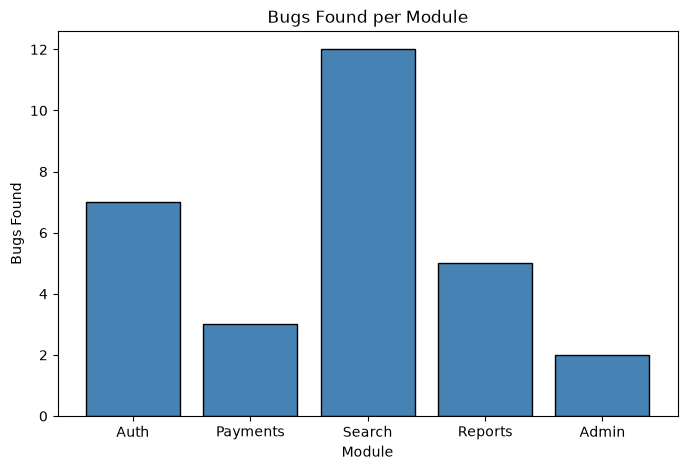

In [5]:
# 1. Daily step count over a month: values over an ordered sequence of days -> line chart
# 2. Bugs found in five modules: comparing quantities across categories -> bar chart
# 3. Distribution of response times: shape of a single numerical variable -> histogram
# 4. Coffee consumption vs productivity: relationship between two numerical variables -> scatter plot
# 5. Percentage of budget per department: proportions of a whole -> pie chart (or a bar chart, which is usually clearer)

# Implementation: bug counts across five modules (a bar chart)
modules = ["Auth", "Payments", "Search", "Reports", "Admin"]
bug_counts = [7, 3, 12, 5, 2]

plt.figure(figsize=(8, 5))
plt.bar(modules, bug_counts, color='steelblue', edgecolor='black')
plt.xlabel('Module')
plt.ylabel('Bugs Found')
plt.title('Bugs Found per Module')
plt.show()


## Writing Reusable Plotting Functions

Just as we wrapped statistical calculations in functions, we can wrap plotting patterns:

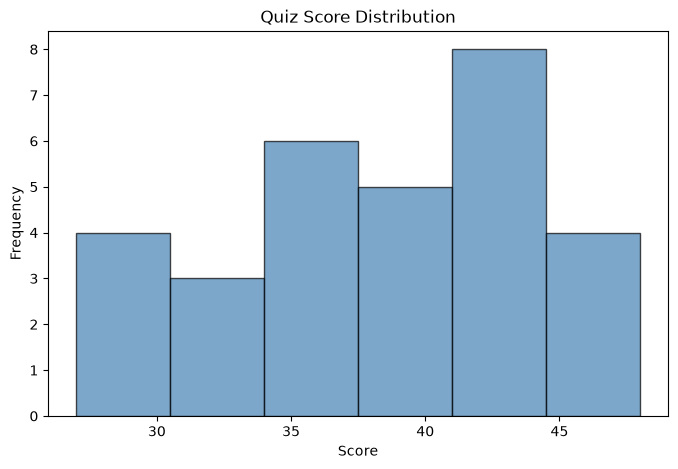

In [6]:
def plot_histogram(data, title, xlabel, num_bins=10, colour='steelblue'):
    """Create a labelled histogram from a list of numerical data."""
    plt.figure(figsize=(8, 5))
    plt.hist(data, bins=num_bins, color=colour, edgecolor='black', alpha=0.7)
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')
    plt.title(title)
    plt.show()

# Now we can create histograms with one line
scores = [42, 38, 35, 47, 29, 41, 44, 33, 39, 48,
          31, 36, 43, 27, 45, 40, 37, 34, 46, 32,
          38, 41, 35, 43, 30, 39, 44, 36, 42, 28]

plot_histogram(scores, 'Quiz Score Distribution', 'Score', num_bins=6)

### Your turn

Write a reusable function `plot_bar_chart(categories, values, title, xlabel, ylabel)` and another `plot_scatter(x, y, title, xlabel, ylabel)`. Include docstrings. Test them with the data from earlier in this tutorial.

In [7]:
def plot_bar_chart(categories, values, title, xlabel, ylabel):
    """Create a labelled bar chart comparing values across categories."""
    plt.figure(figsize=(8, 5))
    plt.bar(categories, values, color='steelblue', edgecolor='black')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()


In [8]:
def plot_scatter(x, y, title, xlabel, ylabel):
    """Create a labelled scatter plot showing the relationship between two numerical variables."""
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, color='coral', edgecolor='black', s=60)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()


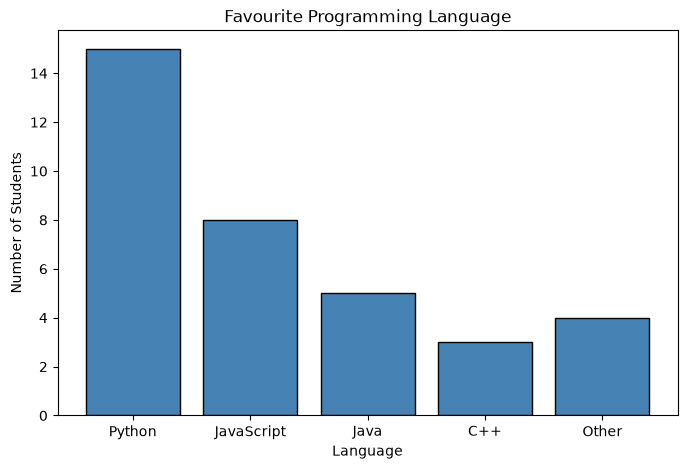

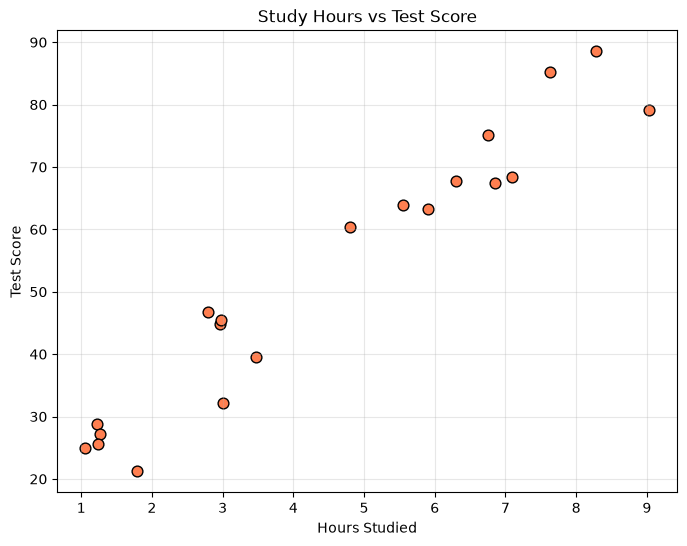

In [9]:
plot_bar_chart(languages, counts, 'Favourite Programming Language', 'Language', 'Number of Students')
plot_scatter(study_hours, test_scores, 'Study Hours vs Test Score', 'Hours Studied', 'Test Score')


## Combining Statistics and Visualisation

The most informative approach is to combine numerical summaries with visual displays. Let's write a function that gives us the full picture:

In [10]:
def analyse_dataset(data, title):
    """Print summary statistics and show a histogram for a dataset."""
    # We are using our functions from Tutorial 11
    # (you may need to redefine mean, median, mode, std_dev here
    #  or copy them from your previous work)
    
    print("=== " + title + " ===")
    print("Count:    ", len(data))
    print("Min:      ", min(data))
    print("Max:      ", max(data))
    # Add calls to mean, median, mode, std_dev here
    print()
    
    plot_histogram(data, title, 'Value')

### Your turn

Complete the `analyse_dataset` function by adding calls to your statistical functions from Tutorial 11. Then use it on the quiz scores. If you want a challenge, create a second dataset and compare the two analyses side by side.

In [11]:
def mean(data):
    """Return the arithmetic mean of a list of numbers. Carried forward from Tutorial 11."""
    return sum(data) / len(data)


def median(data):
    """Return the median of a list of numbers. Carried forward from Tutorial 11."""
    ordered = sorted(data)
    n = len(ordered)
    middle = n // 2
    if n % 2 == 1:
        return ordered[middle]
    return (ordered[middle - 1] + ordered[middle]) / 2


def mode(data):
    """Return the most frequently occurring value(s). Carried forward from Tutorial 11."""
    counts = {}
    for value in data:
        if value in counts:
            counts[value] = counts[value] + 1
        else:
            counts[value] = 1
    highest = max(counts.values())
    return [value for value, count in counts.items() if count == highest]


def std_dev(data):
    """Return the standard deviation of a list of numbers. Carried forward from Tutorial 11."""
    data_mean = mean(data)
    total = 0
    for value in data:
        total = total + (value - data_mean) ** 2
    return (total / len(data)) ** 0.5


def analyse_dataset(data, title):
    """Print summary statistics and show a histogram for a dataset."""
    print("=== " + title + " ===")
    print("Count:    ", len(data))
    print("Min:      ", min(data))
    print("Max:      ", max(data))
    print("Mean:     ", round(mean(data), 2))
    print("Median:   ", median(data))
    print("Mode:     ", mode(data))
    print("Std dev:  ", round(std_dev(data), 2))
    print()

    plot_histogram(data, title, 'Value')


=== Quiz Score Distribution ===
Count:     30
Min:       27
Max:       48
Mean:      38.1
Median:    38.5
Mode:      [42, 38, 35, 41, 44, 39, 36, 43]
Std dev:   5.75



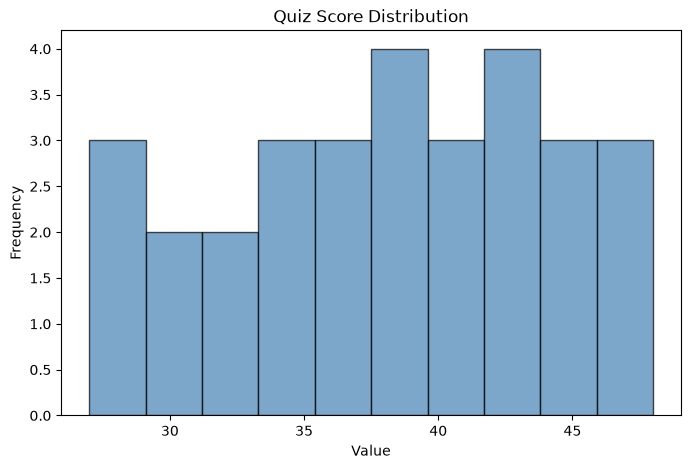

=== Salary Distribution (thousands) ===
Count:     9
Min:       30
Max:       250
Mean:      58.78
Median:    35
Mode:      [35]
Std dev:   67.67



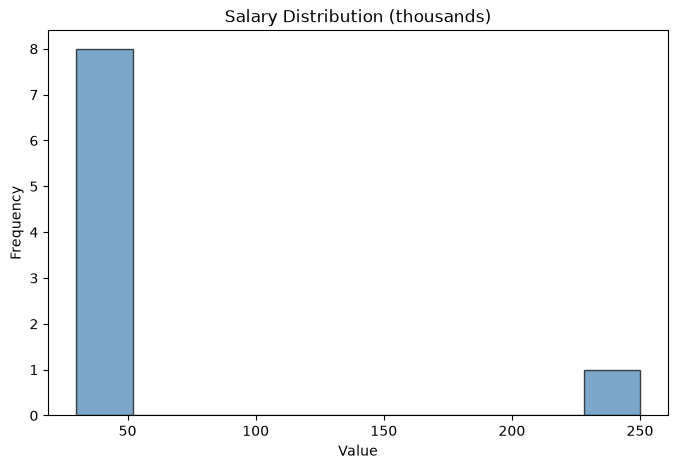

In [12]:
analyse_dataset(scores, 'Quiz Score Distribution')

# A second dataset for comparison
salaries = [30, 32, 33, 35, 35, 36, 38, 40, 250]
analyse_dataset(salaries, 'Salary Distribution (thousands)')


## Good Practices for Visualisation

A few principles that will serve you well:

Every chart should have a clear title and labelled axes. If someone sees the chart without any surrounding text, they should understand what it shows. Colours should be chosen for clarity, not decoration. If you are showing categories, use distinct colours; if you are showing a continuous variable, use a gradient. Avoid chart junk -- decorative elements that do not convey information. Simplicity aids understanding. When comparing groups, use the same scales so differences are not exaggerated or hidden.

### Your turn

Find a chart online (in a news article, a textbook, or a website) that you think communicates well, and one that communicates poorly. Describe what makes each one effective or ineffective:



## Reflection

Visualisation is not a separate skill from statistics -- it is part of the same process of understanding data. A good analyst moves fluidly between numbers and pictures, using each to check and complement the other.

We now have a complete toolkit for exploratory data analysis: counting, probability, summary statistics, and visualisation. In Skills Demo 2A, you will use all of these together.

What is the most important thing you have learned about presenting data?

